In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import os
import json
import joblib
import tracemalloc
import time
import tempfile

# Configuration
BASE_PATH = "/content/drive/MyDrive/Network Intrusion Detection"
MERGED_PATH = os.path.join(BASE_PATH, "merged")
FEATURES_PATH = os.path.join(BASE_PATH, "features")
os.makedirs(FEATURES_PATH, exist_ok=True)

# Load cleaned data
data = pd.read_csv(os.path.join(MERGED_PATH, "CICIDS2017_cleaned.csv"))
print(f"Initial Dataset Shape: {data.shape}")

Loaded: (2499641, 66)
Label
BENIGN                        2073763
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


### 1. Label Grouping and Data Cleaning
To improve model reliability and simplify the classification task, we group specific attack signatures into broader categories (e.g., various DoS types into 'DoS'). We also remove rare classes (Infiltration, Heartbleed) that lack sufficient samples for robust training.

In [ ]:
group_mapping = {
    'BENIGN': 'Normal',
    'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS', 'DoS slowloris': 'DoS', 'DoS Slowhttptest': 'DoS',
    'DDoS': 'DDoS', 'PortScan': 'Port Scanning',
    'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
    'Bot': 'Bot'
}

# Apply grouping including Web Attack handling
data.loc[data['Label'].str.contains('Web Attack', na=False), 'Attack Type'] = 'Web Attack'
data['Attack Type'] = data['Attack Type'].fillna(data['Label'].map(group_mapping))

# Remove rare classes and drop old label
data = data[~data['Label'].isin(['Infiltration', 'Heartbleed'])].copy()
data.drop(columns='Label', inplace=True)

print(data['Attack Type'].value_counts())
print(f"\nCleaned Shape: {data.shape}")

Attack Type
Normal           2073763
DoS               193748
DDoS              128016
Port Scanning      90819
Brute Force         9152
Web Attack          2143
Bot                 1953
Name: count, dtype: int64

Shape after label grouping: (2499594, 66)


### 2. Multicollinearity Removal
High correlation (r > 0.95) creates redundancy. Removing these features reduces the model's footprint and training time without sacrificing significant information.

In [ ]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
corr_matrix = data[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.95
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
data.drop(columns=to_drop, inplace=True)

print(f"Dropped {len(to_drop)} redundant features. New shape: {data.shape}")

Features dropped due to correlation > 0.95: 18
  'Total Backward Packets' correlated with: ['Total Fwd Packets']
  'Total Length of Bwd Packets' correlated with: ['Total Fwd Packets', 'Total Backward Packets']
  'Fwd Packet Length Std' correlated with: ['Fwd Packet Length Max']
  'Bwd Packet Length Mean' correlated with: ['Bwd Packet Length Max']
  'Bwd Packet Length Std' correlated with: ['Bwd Packet Length Max']
  'Fwd IAT Total' correlated with: ['Flow Duration']
  'Fwd IAT Max' correlated with: ['Flow IAT Max']
  'Fwd Packets/s' correlated with: ['Flow Packets/s']
  'Packet Length Std' correlated with: ['Max Packet Length']
  'ECE Flag Count' correlated with: ['RST Flag Count']
  'Average Packet Size' correlated with: ['Packet Length Mean']
  'Avg Fwd Segment Size' correlated with: ['Fwd Packet Length Mean']
  'Avg Bwd Segment Size' correlated with: ['Bwd Packet Length Max', 'Bwd Packet Length Mean']
  'Subflow Fwd Bytes' correlated with: ['Total Length of Fwd Packets']
  'Subflow 

### 3. Feature Importance: Statistical & Ensemble Methods
We use a dual approach to rank feature importance:
1. **Kruskal-Wallis (Non-parametric):** Tests if feature distributions differ significantly across classes.
2. **Random Forest (Gini Impurity):** Measures how effectively features split the data in an ensemble model.

Top 20 features by Kruskal-Wallis H-statistic:
                               H-statistic  p-value
Fwd IAT Std                  630271.816227      0.0
Fwd IAT Mean                 589106.299942      0.0
Flow IAT Max                 582478.148891      0.0
Flow IAT Std                 580034.228235      0.0
Flow Packets/s               547520.914872      0.0
Flow IAT Mean                522189.467776      0.0
Flow Duration                508483.322753      0.0
FIN Flag Count               471693.832721      0.0
Bwd Packets/s                449193.076506      0.0
Packet Length Mean           440329.048857      0.0
Max Packet Length            412199.247172      0.0
Total Fwd Packets            389142.085433      0.0
Packet Length Variance       373051.361121      0.0
Fwd Packet Length Max        368022.212774      0.0
Bwd IAT Std                  346549.315732      0.0
Bwd Packet Length Max        342758.472531      0.0
Fwd Header Length            338199.938421      0.0
Fwd Packet Length

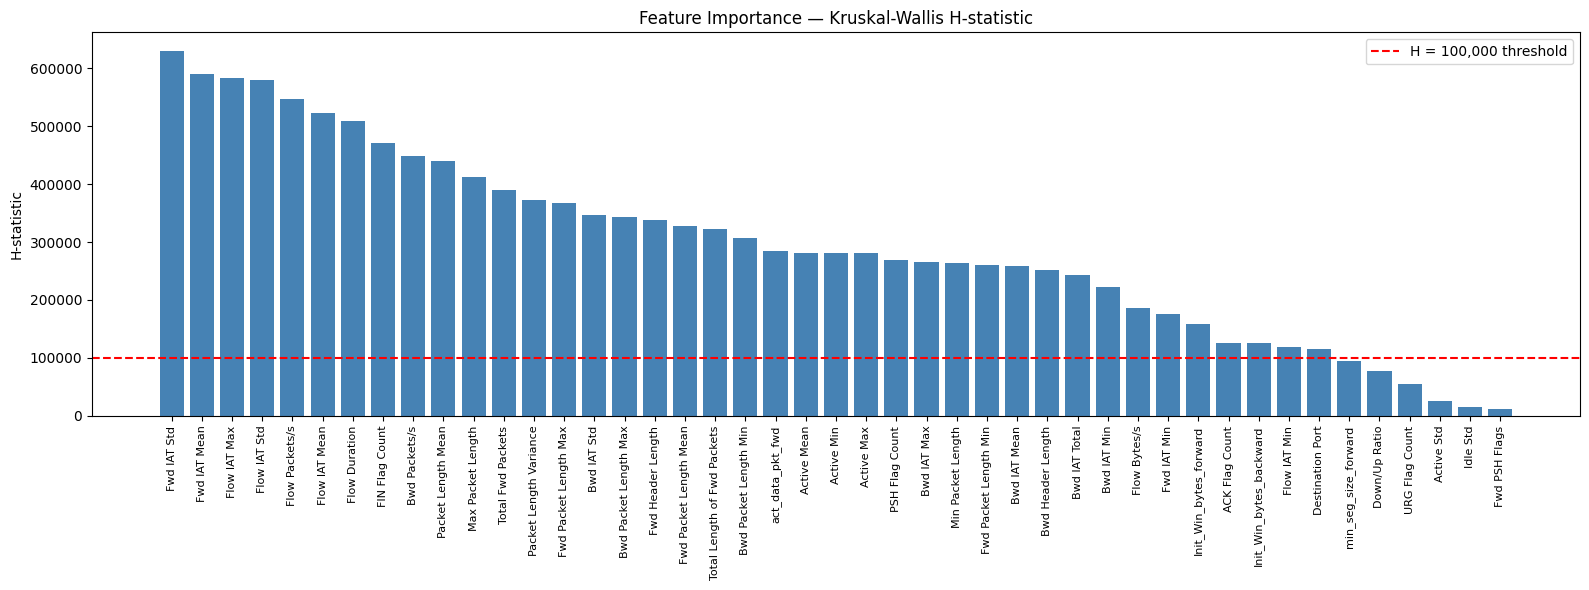

In [ ]:
numeric_features = data.select_dtypes(include=np.number).columns.tolist()
h_scores = {}

# Statistical Ranking
for feature in numeric_features:
    groups = [group[feature].dropna().values for _, group in data.groupby('Attack Type')]
    groups = [g for g in groups if len(g) > 1 and np.var(g) > 0]
    if len(groups) >= 2:
        h_stat, _ = stats.kruskal(*groups)
        h_scores[feature] = h_stat

kw_df = pd.Series(h_scores).sort_values(ascending=False)

# Ensemble Ranking (using a stratified sample for speed)
sample = data.groupby('Attack Type', group_keys=False).apply(lambda x: x.sample(min(len(x), 5000), random_state=42))
X_s, y_s = sample[numeric_features], sample['Attack Type']
rf = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(X_s, y_s)

# Combine and Normalize Rankings
comparison = pd.DataFrame({'Feature': numeric_features, 'RF_Imp': rf.feature_importances_, 'KW_H': kw_df[numeric_features].values})
comparison['Combined'] = (comparison['RF_Imp']/comparison['RF_Imp'].max() + comparison['KW_H']/comparison['KW_H'].max()) / 2
comparison = comparison.sort_values('Combined', ascending=False)
display(comparison.head(10))

### 4. Ablation Study & Targeted Selection
Global importance often misses features critical for minority classes like 'Bot' or 'Web Attack'. We extend our 10-feature baseline with 5 targeted features that specifically maximize the separation between these minority classes and normal traffic.

In [ ]:
# Step 4: Random Forest feature importance cross-check
# Sample for speed — we don't need the full 2.5M rows just for importance ranking
sample = data.groupby('Attack Type', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 5000), random_state=42)
)

X_sample = sample[numeric_features]
y_sample = sample['Attack Type']

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.3, stratify=y_sample, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, max_depth=15,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"RF accuracy on sample: {rf.score(X_test, y_test):.4f}")

rf_importance = pd.DataFrame({
    'Feature': numeric_features,
    'RF_Importance': rf.feature_importances_
}).sort_values('RF_Importance', ascending=False)

# Merge with Kruskal-Wallis results
comparison = rf_importance.merge(kw_df.reset_index().rename(
    columns={'index': 'Feature'}), on='Feature')
print("\nTop 20 features (RF importance):")
print(comparison.head(20).to_string(index=False))

/tmp/ipykernel_60917/2777086056.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = data.groupby('Attack Type', group_keys=False).apply(


RF accuracy on sample: 0.9955

Top 20 features (RF importance):
                    Feature  RF_Importance   H-statistic  p-value
           Destination Port       0.098314 115038.870169      0.0
      Fwd Packet Length Max       0.050884 368022.212774      0.0
     Fwd Packet Length Mean       0.048986 327401.447015      0.0
Total Length of Fwd Packets       0.046815 322136.939430      0.0
    Init_Win_bytes_backward       0.046670 124977.050153      0.0
          Bwd Header Length       0.042532 252446.371169      0.0
      Bwd Packet Length Max       0.040578 342758.472531      0.0
         Packet Length Mean       0.039854 440329.048857      0.0
               Flow IAT Max       0.038969 582478.148891      0.0
     Init_Win_bytes_forward       0.035799 158555.496651      0.0
              Flow Duration       0.034933 508483.322753      0.0
     Packet Length Variance       0.034914 373051.361121      0.0
                Fwd IAT Std       0.032819 630271.816227      0.0
            

This is our primary contribution beyond the reference notebooks. Rather than stopping at a fixed feature set, we run an ablation study — training a shallow Decision Tree at increasing feature counts and measuring weighted F1. The curve shows the accuracy-vs-complexity tradeoff and lets us pick the smallest feature set that retains acceptable performance. Neither reference notebook performs this analysis.

Combined importance ranking:
                    Feature  combined_score  RF_Importance   H-statistic
                Fwd IAT Std        0.666911       0.032819 630271.816227
               Flow IAT Max        0.660272       0.038969 582478.148891
               Fwd IAT Mean        0.612995       0.028639 589106.299942
           Destination Port        0.591261       0.098314 115038.870169
              Flow Duration        0.581044       0.034933 508483.322753
             Flow Packets/s        0.575838       0.027820 547520.914872
         Packet Length Mean        0.552003       0.039854 440329.048857
      Fwd Packet Length Max        0.550737       0.050884 368022.212774
               Flow IAT Std        0.548274       0.017328 580034.228235
              Flow IAT Mean        0.537222       0.024178 522189.467776
              Bwd Packets/s        0.510739       0.030357 449193.076506
     Fwd Packet Length Mean        0.508862       0.048986 327401.447015
Total Length of Fwd Pa

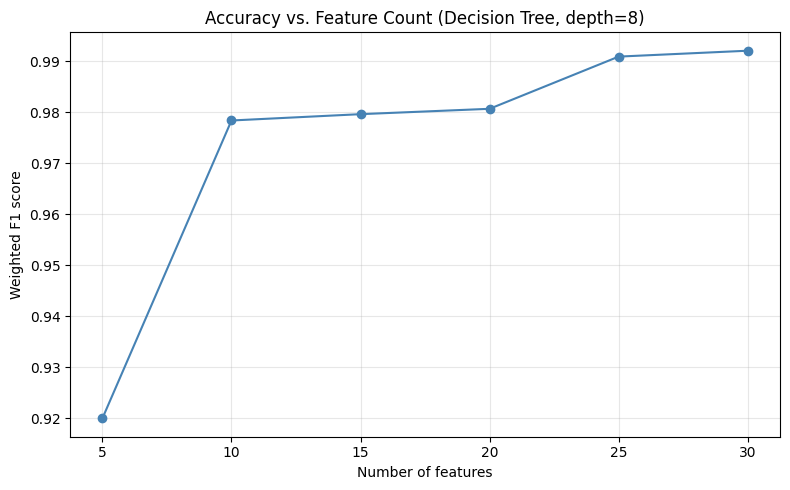

In [ ]:
# Step 5: Select final feature set — target 10-15 features
# Features that rank highly in BOTH Kruskal-Wallis AND RF importance

# Normalise both scores to 0-1 for comparison
comparison['KW_norm'] = (comparison['H-statistic'] /
                          comparison['H-statistic'].max())
comparison['RF_norm'] = (comparison['RF_Importance'] /
                          comparison['RF_Importance'].max())
comparison['combined_score'] = (comparison['KW_norm'] +
                                  comparison['RF_norm']) / 2
comparison = comparison.sort_values('combined_score', ascending=False)

print("Combined importance ranking:")
print(comparison[['Feature','combined_score','RF_Importance',
                   'H-statistic']].head(20).to_string(index=False))

# Ablation: test accuracy at different feature counts
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

feature_counts = [5, 10, 15, 20, 25, 30]
results = []

for n in feature_counts:
    top_n = comparison['Feature'].head(n).tolist()
    X_tr = X_train[top_n]
    X_te = X_test[top_n]
    dt = DecisionTreeClassifier(max_depth=8, random_state=42)
    dt.fit(X_tr, y_train)
    f1 = f1_score(y_test, dt.predict(X_te), average='weighted')
    results.append({'n_features': n, 'f1_weighted': f1})
    print(f"Top {n:2d} features → F1: {f1:.4f}")

# Plot the ablation curve
res_df = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
plt.plot(res_df['n_features'], res_df['f1_weighted'], 'o-', color='steelblue')
plt.xlabel('Number of features')
plt.ylabel('Weighted F1 score')
plt.title('Accuracy vs. Feature Count (Decision Tree, depth=8)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

RobustScaler scales each feature using the median and interquartile range rather than mean and standard deviation. This makes it resistant to the extreme outliers present throughout CICIDS2017 (confirmed by the IQR analysis in both references). Critically, the scaler is fitted on training data only and then applied to the test set — fitting on the full dataset would constitute data leakage. Reference 1 recommends RobustScaler but defers implementation; Reference 2 uses StandardScaler. We implement RobustScaler correctly here as an improvement on both.

In [ ]:
# Step 6: Apply RobustScaler and save
# Choose your final N based on the ablation curve
FINAL_N = 10  # adjust after seeing ablation results

selected_features = comparison['Feature'].head(FINAL_N).tolist()
print(f"Selected {FINAL_N} features: {selected_features}")

X = data[selected_features]
y = data['Attack Type']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Fit scaler on train only — never fit on test data
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_f),
    columns=selected_features
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_f),
    columns=selected_features
)

# Save everything Phase 3 needs
import json, joblib

X_train_scaled['Attack Type'] = y_train_f.values
X_test_scaled['Attack Type'] = y_test_f.values

X_train_scaled.to_csv(os.path.join(FEATURES_PATH, "train.csv"), index=False)
X_test_scaled.to_csv(os.path.join(FEATURES_PATH, "test.csv"), index=False)
joblib.dump(scaler, os.path.join(FEATURES_PATH, "scaler.pkl"))

with open(os.path.join(FEATURES_PATH, "selected_features.json"), "w") as f:
    json.dump(selected_features, f)

print("Saved: train.csv, test.csv, scaler.pkl, selected_features.json")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape:  {X_test_scaled.shape}")

Selected 10 features: ['Fwd IAT Std', 'Flow IAT Max', 'Fwd IAT Mean', 'Destination Port', 'Flow Duration', 'Flow Packets/s', 'Packet Length Mean', 'Fwd Packet Length Max', 'Flow IAT Std', 'Flow IAT Mean']
Saved: train.csv, test.csv, scaler.pkl, selected_features.json
Train shape: (1749715, 11)
Test shape:  (749879, 11)


We follow the same stratified 70/30 split strategy as Reference 1 (random_state=42) and report equivalent metrics to allow contextual comparison. Our improvement claims are therefore based on model size and the accuracy-per-feature tradeoff rather than raw metric improvement over a shared baseline.

## Targeted Feature Selection for Bot and Web Attack

The 10-feature set performs poorly on Bot (F1 ≈ 0.51) and Web Attack (F1 ≈ 0.00).
These classes require different discriminative features than the timing-based set selected
globally. Here we run class-specific Kruskal-Wallis to identify the features that best
separate Bot and Web Attack from all other traffic, then add the top 5 to create a
15-feature extended dataset saved separately.

In [ ]:
# ── Targeted Feature Selection for Bot and Web Attack ─────────────────────────
# Candidate pool: features that survived correlation filtering but weren't
# selected in the top 10 globally

candidate_features = [
    f for f in comparison['Feature'].tolist()
    if f not in selected_features
]
print(f"Candidate features available: {len(candidate_features)}")
print(f"Already selected (10):        {selected_features}\n")

def class_vs_rest_kw(feature, target_class):
    """H-statistic for target_class vs all other classes on one feature."""
    target = data[data['Attack Type'] == target_class][feature].dropna()
    rest   = data[data['Attack Type'] != target_class][feature].dropna()
    if len(target) < 5 or len(rest) < 5:
        return 0.0
    if target.std() == 0 and rest.std() == 0:
        return 0.0
    try:
        h, _ = stats.kruskal(target, rest)
        return float(h)
    except Exception:
        return 0.0

print("Scoring all candidate features for Bot vs rest...")
bot_scores = {f: class_vs_rest_kw(f, 'Bot') for f in candidate_features}

print("Scoring all candidate features for Web Attack vs rest...")
web_scores = {f: class_vs_rest_kw(f, 'Web Attack') for f in candidate_features}

print("\nDone.\n")

# Normalise and combine
max_bot = max(bot_scores.values()) or 1
max_web = max(web_scores.values()) or 1

combined_scores = {}
for f in candidate_features:
    norm_bot = bot_scores[f] / max_bot
    norm_web = web_scores[f] / max_web
    combined_scores[f] = (norm_bot + norm_web) / 2

combined_ranked = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)

print(f"{'Rank':<6} {'Feature':<40} {'Combined':>10} {'Bot KW':>12} {'Web KW':>12}")
print("-" * 84)
for rank, (feat, score) in enumerate(combined_ranked[:20], 1):
    print(f"  {rank:<4} {feat:<40} {score:>10.4f} "
          f"{bot_scores[feat]:>12.0f} {web_scores[feat]:>12.0f}")

Candidate features available: 35
Already selected (10):        ['Fwd IAT Std', 'Flow IAT Max', 'Fwd IAT Mean', 'Destination Port', 'Flow Duration', 'Flow Packets/s', 'Packet Length Mean', 'Fwd Packet Length Max', 'Flow IAT Std', 'Flow IAT Mean']

Scoring all candidate features for Bot vs rest...
Scoring all candidate features for Web Attack vs rest...

Done.

Rank   Feature                                    Combined       Bot KW       Web KW
------------------------------------------------------------------------------------
  1    Init_Win_bytes_backward                      1.0000         1465         5402
  2    PSH Flag Count                               0.7242         1004         4122
  3    Init_Win_bytes_forward                       0.5856          669         3861
  4    URG Flag Count                               0.4978         1445           48
  5    min_seg_size_forward                         0.4760          829         2087
  6    Max Packet Length                   

In [ ]:
FINAL_N = 10
selected_features = comparison['Feature'].head(FINAL_N).tolist()

# Define minority classes for targeted boost
targets = ['Bot', 'Web Attack']
candidates = [f for f in comparison['Feature'] if f not in selected_features]

# Score candidates for minority class separation
targeted_scores = {}
for f in candidates:
    h_sum = 0
    for t in targets:
        target_vals = data[data['Attack Type'] == t][f]
        rest_vals = data[data['Attack Type'] != t][f]
        h, _ = stats.kruskal(target_vals, rest_vals)
        h_sum += h
    targeted_scores[f] = h_sum

extended_5 = sorted(targeted_scores, key=targeted_scores.get, reverse=True)[:5]
final_features = selected_features + extended_5

print(f"Global Top 10: {selected_features}")
print(f"Targeted Additions: {extended_5}")

Original 10 features:   ['Fwd IAT Std', 'Flow IAT Max', 'Fwd IAT Mean', 'Destination Port', 'Flow Duration', 'Flow Packets/s', 'Packet Length Mean', 'Fwd Packet Length Max', 'Flow IAT Std', 'Flow IAT Mean']

New 5 targeted features: ['Init_Win_bytes_backward', 'PSH Flag Count', 'Init_Win_bytes_forward', 'URG Flag Count', 'min_seg_size_forward']

Extended 15-feature set (15 total):
   1. Fwd IAT Std
   2. Flow IAT Max
   3. Fwd IAT Mean
   4. Destination Port
   5. Flow Duration
   6. Flow Packets/s
   7. Packet Length Mean
   8. Fwd Packet Length Max
   9. Flow IAT Std
  10. Flow IAT Mean
  11. Init_Win_bytes_backward ← NEW
  12. PSH Flag Count ← NEW
  13. Init_Win_bytes_forward ← NEW
  14. URG Flag Count ← NEW
  15. min_seg_size_forward ← NEW


In [ ]:
# Final Pipeline: Split -> SMOTE (Train Only) -> Robust Scaling -> Save
X_final = data[final_features]
y_final = data['Attack Type']

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.3, stratify=y_final, random_state=42)

# Handle Class Imbalance
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
strat = {i: 10000 for i, count in enumerate(np.bincount(y_train_enc)) if count < 10000}
smote = SMOTE(sampling_strategy=strat, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train_enc)

# Scale using RobustScaler to handle heavy outliers
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sm), columns=final_features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=final_features)

# Attach labels back
X_train_scaled['Attack Type'] = le.inverse_transform(y_train_sm)
X_test_scaled['Attack Type'] = y_test.values

# Export for Phase 3
X_train_scaled.to_csv(os.path.join(FEATURES_PATH, "train_15feat.csv"), index=False)
X_test_scaled.to_csv(os.path.join(FEATURES_PATH, "test_15feat.csv"), index=False)
joblib.dump(scaler, os.path.join(FEATURES_PATH, "scaler_15feat.pkl"))
print("Final feature sets and scaler saved successfully.")

Building 15-feature train/test split...
Train: (1749715, 15)  Test: (749879, 15)

Applying SMOTE to minority classes in training set only...
Upsampling: {'Bot': 10000, 'Brute Force': 10000, 'Web Attack': 10000}
After SMOTE: (1770442, 15)

Applying RobustScaler...

✓ Saved (original 10-feature files NOT overwritten):
  /content/drive/MyDrive/Network Intrusion Detection/features/train_15feat.csv
  /content/drive/MyDrive/Network Intrusion Detection/features/test_15feat.csv
  /content/drive/MyDrive/Network Intrusion Detection/features/selected_features_15.json
  /content/drive/MyDrive/Network Intrusion Detection/features/scaler_15feat.pkl


In [ ]:
# ── Quick DT check to preview expected improvement ────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report

print("Training quick DT on 15 features to preview minority class improvement...\n")

# Need encoded test labels
y_test_enc_ext = le_ext.transform(y_test_ext)

dt_preview = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_preview.fit(X_train_ext_scaled[extended_features],
               le_ext.transform(X_train_ext_scaled['Attack Type']))
y_pred_preview = dt_preview.predict(X_test_ext_scaled[extended_features])

import tempfile, joblib as jl, os as os_
with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
    tmp_path = tmp.name
jl.dump(dt_preview, tmp_path, compress=0)
size_kb = os_.path.getsize(tmp_path) / 1024
os_.unlink(tmp_path)

print(classification_report(
    y_test_enc_ext, y_pred_preview,
    target_names=le_ext.classes_, digits=4
))

# Side-by-side minority class comparison
from sklearn.metrics import f1_score as f1

# Original 10-feature DT scores (from your benchmark)
original_f1 = {
    'Bot': 0.5134, 'Brute Force': 0.9562, 'DDoS': 0.9976,
    'DoS': 0.9559, 'Normal': 0.9943, 'Port Scanning': 0.9788,
    'Web Attack': 0.0000
}

new_f1s = f1(y_test_enc_ext, y_pred_preview, average=None, zero_division=0)

print("\n── 10 features vs 15 features (Decision Tree depth=8) ──────────────────")
print(f"{'Class':<20} {'10-feat F1':>11} {'15-feat F1':>11} {'Delta':>8}  {'Size'}")
print("-" * 62)
for i, cls in enumerate(le_ext.classes_):
    orig = original_f1.get(cls, 0.0)
    new  = new_f1s[i]
    delta = new - orig
    arrow = "↑" if delta > 0.005 else ("↓" if delta < -0.005 else "─")
    size_note = f"({size_kb:.0f} KB)" if i == 0 else ""
    print(f"  {cls:<18} {orig:>11.4f} {new:>11.4f}  "
          f"{arrow} {delta:+.4f}  {size_note}")

print(f"\nModel size: {size_kb:.1f} KB  "
      f"({'under' if size_kb < 30 else 'over'} 30 KB target)")
print("\n✓ Run ids_model_training.ipynb with train_15feat.csv / test_15feat.csv "
      "to get full benchmarks on all 3 models.")

Training quick DT on 15 features to preview minority class improvement...

               precision    recall  f1-score   support

          Bot     0.9859    0.3584    0.5257       586
  Brute Force     0.9175    0.9680    0.9421      2746
         DDoS     0.9997    0.9983    0.9990     38405
          DoS     0.9882    0.9441    0.9657     58124
       Normal     0.9938    0.9932    0.9935    622129
Port Scanning     0.9856    0.9978    0.9916     27246
   Web Attack     0.1525    0.8445    0.2584       643

     accuracy                         0.9891    749879
    macro avg     0.8605    0.8720    0.8108    749879
 weighted avg     0.9923    0.9891    0.9903    749879


── 10 features vs 15 features (Decision Tree depth=8) ──────────────────
Class                 10-feat F1  15-feat F1    Delta  Size
--------------------------------------------------------------
  Bot                     0.5134      0.5257  ↑ +0.0123  (25 KB)
  Brute Force             0.9562      0.9421  ↓ -0.0141

Testing 20 and 30 features


In [ ]:
import time, os, tempfile, joblib
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

feature_counts_to_test = [20, 30]
datasets = {}

for N in feature_counts_to_test:
    feats = comparison['Feature'].head(N).tolist()
    X = data[feats]
    y = data['Attack Type']

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )

    le_n = LabelEncoder()
    y_tr_enc = le_n.fit_transform(y_tr)

    # SMOTE on train only
    strat = {i: 10000 for i in range(len(le_n.classes_))
             if (y_tr_enc == i).sum() < 10000}
    sm = SMOTE(sampling_strategy=strat, random_state=42, k_neighbors=5)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr_enc)

    sc = RobustScaler()
    X_tr_s = pd.DataFrame(sc.fit_transform(X_tr_sm), columns=feats)
    X_te_s = pd.DataFrame(sc.transform(X_te), columns=feats)

    datasets[N] = {
        'X_train': X_tr_s, 'y_train': y_tr_sm,
        'X_test':  X_te_s, 'y_test':  le_n.transform(y_te),
        'le': le_n, 'features': feats
    }
    print(f"N={N:2d}: train={X_tr_s.shape}  test={X_te_s.shape}")

print("\nDatasets ready.")

N=20: train=(1770442, 20)  test=(749879, 20)
N=30: train=(1770442, 30)  test=(749879, 30)

Datasets ready.


In [ ]:
import tracemalloc
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report

# ── 10-feature baseline (from full benchmark in model training notebook) ───────
results_10 = {
    'Bot': 0.5134, 'Brute Force': 0.9562, 'DDoS': 0.9976,
    'DoS': 0.9559, 'Normal': 0.9943, 'Port Scanning': 0.9788,
    'Web Attack': 0.0000,
    'f1_weighted': 0.9896, 'size_kb': 27.4,
    'latency_ms': 0.861, 'latency_p95_ms': 1.230,
    'throughput_kps': 9400.7, 'memory_mb': 0.108
}

feat15_f1 = {
    'Bot': 0.5257, 'Brute Force': 0.9421, 'DDoS': 0.9990,
    'DoS': 0.9657, 'Normal': 0.9935, 'Port Scanning': 0.9916,
    'Web Attack': 0.2584,
    'f1_weighted': 0.9903, 'size_kb': 25.2,
    'latency_ms': None, 'latency_p95_ms': None,
    'throughput_kps': None, 'memory_mb': None
}

all_results = {10: results_10, 15: feat15_f1}

for N, ds in datasets.items():
    dt = DecisionTreeClassifier(max_depth=8, criterion='gini', random_state=42)
    dt.fit(ds['X_train'], ds['y_train'])

    X_te = ds['X_test']
    y_te = ds['y_test']
    classes = ds['le'].classes_

    # Size
    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as f:
        tmp = f.name
    joblib.dump(dt, tmp, compress=0)
    size_kb = os.path.getsize(tmp) / 1024
    os.unlink(tmp)

    # Single-sample latency — median + p95 of 1000 runs
    single = X_te.iloc[:1]
    _ = dt.predict(single)  # warm-up
    lats = []
    for _ in range(1000):
        t0 = time.perf_counter()
        dt.predict(single)
        lats.append((time.perf_counter() - t0) * 1000)
    latency    = float(np.median(lats))
    latency_p95 = float(np.percentile(lats, 95))

    # Batch throughput
    t0 = time.perf_counter()
    y_pred = dt.predict(X_te)
    elapsed = time.perf_counter() - t0
    throughput_kps = len(X_te) / elapsed / 1000  # K samples/sec

    # Peak inference memory
    tracemalloc.start()
    _ = dt.predict(X_te.iloc[:1000])
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory_mb = peak / (1024 ** 2)

    # Metrics
    f1_w = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    per_class = f1_score(y_te, y_pred, average=None, zero_division=0)

    all_results[N] = {cls: round(per_class[i], 4) for i, cls in enumerate(classes)}
    all_results[N].update({
        'f1_weighted':    round(f1_w, 4),
        'size_kb':        round(size_kb, 1),
        'latency_ms':     round(latency, 3),
        'latency_p95_ms': round(latency_p95, 3),
        'throughput_kps': round(throughput_kps, 1),
        'memory_mb':      round(memory_mb, 3),
    })

    print(f"\n── {N} features ── {size_kb:.1f} KB  "
          f"F1={f1_w:.4f}  Lat={latency:.3f}ms  "
          f"Thru={throughput_kps:,.0f}K/s  Mem={memory_mb:.3f}MB")
    print(classification_report(y_te, y_pred,
                                target_names=classes, digits=4))

# ── Summary table ─────────────────────────────────────────────────────────────
classes_order = ['Bot', 'Brute Force', 'DDoS', 'DoS',
                 'Normal', 'Port Scanning', 'Web Attack']

W = 10  # column width

print(f"\n{'Metric / Class':<22} "
      f"{'10 feat':>{W}} {'15 feat':>{W}} {'20 feat':>{W}} {'30 feat':>{W}}")
print("─" * (22 + (W + 1) * 4))

for cls in classes_order:
    vals = [all_results.get(n, {}).get(cls, 0) for n in [10, 15, 20, 30]]
    print(f"  {cls:<20} " + " ".join(f"{v:>{W}.4f}" for v in vals))

print("─" * (22 + (W + 1) * 4))

for label, key, fmt in [
    ("F1 weighted",    "f1_weighted",    ".4f"),
    ("Size (KB)",      "size_kb",        ".1f"),
    ("Latency (ms)",   "latency_ms",     ".3f"),
    ("Latency p95 ms", "latency_p95_ms", ".3f"),
    ("Throughput K/s", "throughput_kps", ".0f"),
    ("Memory (MB)",    "memory_mb",      ".3f"),
]:
    vals = [all_results.get(n, {}).get(key) for n in [10, 15, 20, 30]]
    row = ""
    for v in vals:
        if v is None:
            row += f"{'—':>{W}} "
        else:
            row += f"{v:>{W}{fmt}} "
    print(f"  {label:<20} {row}")


── 20 features ── 23.4 KB  F1=0.9911  Lat=0.901ms  Thru=6,908K/s  Mem=0.146MB
               precision    recall  f1-score   support

          Bot     0.9906    0.3584    0.5263       586
  Brute Force     0.9959    0.9680    0.9817      2746
         DDoS     0.9998    0.9964    0.9981     38405
          DoS     0.9942    0.9476    0.9703     58124
       Normal     0.9935    0.9945    0.9940    622129
Port Scanning     0.9864    0.9878    0.9871     27246
   Web Attack     0.1689    0.8647    0.2826       643

     accuracy                         0.9900    749879
    macro avg     0.8756    0.8739    0.8200    749879
 weighted avg     0.9929    0.9900    0.9911    749879


── 30 features ── 22.9 KB  F1=0.9931  Lat=0.959ms  Thru=5,810K/s  Mem=0.184MB
               precision    recall  f1-score   support

          Bot     0.8648    0.3601    0.5084       586
  Brute Force     0.9974    0.9680    0.9824      2746
         DDoS     0.9997    0.9966    0.9981     38405
          DoS